Avvio Ottimizzazione Bayesiana...

Test in corso: p[0]=4.3896, p[1]=0.9284, p[2]=1.3458... Energia = 0.169664
Test in corso: p[0]=3.7906, p[1]=1.1121, p[2]=0.8700... Energia = 0.148116
Test in corso: p[0]=3.3777, p[1]=1.0336, p[2]=0.9000... Energia = 0.146783
Test in corso: p[0]=3.9527, p[1]=0.8395, p[2]=1.3054... Energia = 0.166089
Test in corso: p[0]=4.8157, p[1]=0.8005, p[2]=1.4945... Energia = 0.177865
Test in corso: p[0]=4.3751, p[1]=1.4954, p[2]=1.0581... Energia = 0.158089
Test in corso: p[0]=2.0000, p[1]=1.5000, p[2]=0.8000... Energia = 0.256935
Test in corso: p[0]=5.0000, p[1]=1.1253, p[2]=0.8000... Energia = 0.165712
Test in corso: p[0]=3.5138, p[1]=1.5000, p[2]=0.8000... Energia = 0.154273
Test in corso: p[0]=3.4940, p[1]=0.8000, p[2]=0.8000... Energia = 0.152698
Test in corso: p[0]=2.6513, p[1]=0.8000, p[2]=1.5000... Energia = 0.197551
Test in corso: p[0]=3.4245, p[1]=0.8749, p[2]=1.4990... Energia = 0.178503
Test in corso: p[0]=3.4931, p[1]=0.8000, p[2]=1.0619... Energia =

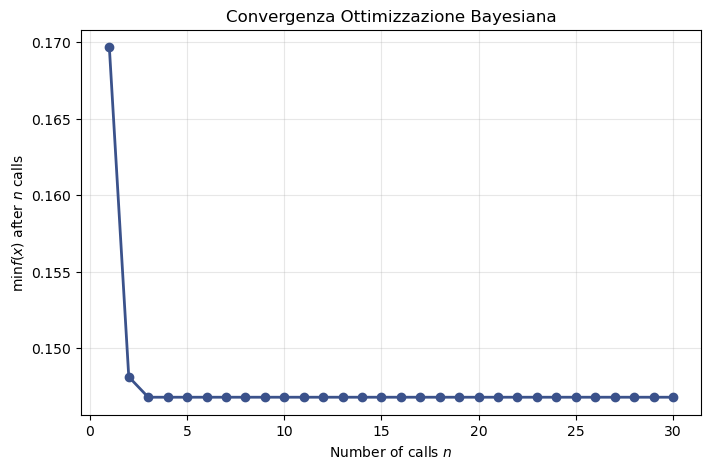


Generazione mappa del modello surrogato...


<Figure size 1000x1000 with 0 Axes>

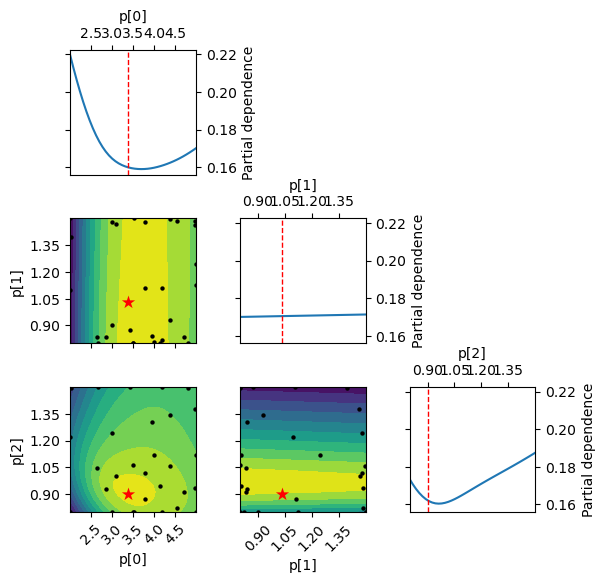

In [2]:
import subprocess
import re
import json
import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
import matplotlib.pyplot as plt
from skopt.plots import plot_convergence, plot_objective

# ==========================================
# 1. DEFINIZIONE DELLO SPAZIO DEI PARAMETRI
# ==========================================
# Imposta i lower/upper bounds per p[0], p[1], p[2]
space = [
    Real(2.0, 5.0, name='p0'),
    Real(0.8, 1.5, name='p1'),
    Real(0.8, 1.5, name='p2')
]

# ==========================================
# 2. FUNZIONE OBIETTIVO (Il "Direttore")
# ==========================================
@use_named_args(space)
def evaluate_vmc(p0, p1, p2):
    print(f"Test in corso: p[0]={p0:.4f}, p[1]={p1:.4f}, p[2]={p2:.4f}...", end=" ")
    
    # --- FASE A: Aggiorna i parametri di input ---
    # Qui supponiamo che tu legga i parametri dal JSON.
    # Modifica il nome del file e le chiavi in base al tuo setup reale!
    config_file = 'config.json'
    try:
        with open(config_file, 'r') as f:
            config = json.load(f)
            
        config["physics"]['jsonParams'] = [float(p0), float(p1), float(p2)]
        
        with open(config_file, 'w') as f:
            json.dump(config, f, indent=4)
    except FileNotFoundError:
        print(f"\n[!] Errore: {config_file} non trovato. Assicurati di essere nella directory corretta.")
        return 1000.0 # Valore di penalità
        
    # --- FASE B: Esegui il programma C++ ---
    # Sostituisci './vmc_executable' con il nome reale del tuo programma compilato
    exe_name = './vmc_release'
    try:
        # Esegue il programma e cattura l'output del terminale
        result = subprocess.run([exe_name, '2'], capture_output=True, text=True, check=True)
    except subprocess.CalledProcessError as e:
        print("\n[!] Il programma C++ ha generato un errore.")
        return 1000.0
        
    # --- FASE C: Leggi l'energia dall'output ---
    # Cerchiamo la riga "Final blocking energy: X.XXX +- Y.YYY" 
    # che hai mostrato nei tuoi file log.
    match = re.search(r"Final blocking energy:\s*([0-9\.eE\+\-]+)", result.stdout)
    if match:
        energy = float(match.group(1))
        print(f"Energia = {energy:.6f}")
        
        # Opzionale: gestire le energie palesemente sballate (i collassi nel core)
        if energy > 10.0 or energy < -10.0:
            return 1000.0
            
        return energy
    else:
        print("\n[!] Non sono riuscito a trovare l'energia nell'output.")
        return 1000.0

# ==========================================
# 3. ESECUZIONE DELL'OTTIMIZZAZIONE BAYESIANA
# ==========================================
if __name__ == "__main__":
    print("Avvio Ottimizzazione Bayesiana...\n")
    
    # Esegue il Gaussian Process Minimization
    res = gp_minimize(
        func=evaluate_vmc,
        dimensions=space,
        n_calls=30,           # Numero totale di simulazioni VMC da lanciare
        n_initial_points=5,   # Primi punti casuali per "mappare" il terreno
        acq_func="EI",        # Expected Improvement (bilancia esplorazione e sfruttamento)
        random_state=42       # Seed per riproducibilità
    )

    # ==========================================
    # 4. RISULTATI E VISUALIZZAZIONE
    # ==========================================
    print("\n" + "="*40)
    print("      OTTIMIZZAZIONE COMPLETATA")
    print("="*40)
    print(f"Migliore Energia Trovata: {res.fun:.6f}")
    print(f"Parametri Ottimali:")
    print(f"  p[0] = {res.x[0]:.6f}")
    print(f"  p[1] = {res.x[1]:.6f}")
    print(f"  p[2] = {res.x[2]:.6f}")
    
    # Plotta la convergenza
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_convergence(res, ax=ax)
    ax.set_title("Convergenza Ottimizzazione Bayesiana")
    ax.grid(True, alpha=0.3)
    plt.show()
    
    # Plotta i "Partial Dependences" (la mappa del modello surrogato)
    print("\nGenerazione mappa del modello surrogato...")
    fig2 = plt.figure(figsize=(10, 10))
    _ = plot_objective(res, dimensions=['p[0]', 'p[1]', 'p[2]'])
    plt.show()